# Feature Ablation Study

Test which metadata feature groups leak the most device identity information

- Packet count only
- Byte count only
- Direction only
- Packet size only
- Burst features only
- All features

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

input_path = "extracted_data"

feature_files = {
    "2018-03-20": f"input_path/features_2018_03_20.csv",
    "2018-03-21": f"input_path/features_2018_03_21.csv",
}

## Feature Grouping

In [2]:
def filter_labels_for_same_day(df, min_samples=10):
    counts = df["label"].value_counts()
    labels = counts[counts >= min_samples].index
    return df[df["label"].isin(labels)].copy()


def add_basic_features(df):
    df = df.copy()
    eps = 1e-9
    df["outgoing_pkt_share"] = df["outgoing_pkts"] / (df["pkt_count"] + eps)
    df["incoming_pkt_share"] = df["incoming_pkts"] / (df["pkt_count"] + eps)
    df["outgoing_byte_share"] = df["outgoing_bytes"] / (df["total_bytes"] + eps)
    df["incoming_byte_share"] = df["incoming_bytes"] / (df["total_bytes"] + eps)
    df["pkt_size_range"] = df["max_pkt_size"] - df["min_pkt_size"]
    df["bytes_per_packet"] = df["total_bytes"] / (df["pkt_count"] + eps)
    return df


def add_burst_features(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    pkt_q90 = max(float(train_df["pkt_count"].quantile(0.90)), 1.0)
    byte_q90 = max(float(train_df["total_bytes"].quantile(0.90)), 1.0)

    for df in (train_df, test_df):
        df["pkt_burst"] = (df["pkt_count"] >= pkt_q90).astype(int)
        df["byte_burst"] = (df["total_bytes"] >= byte_q90).astype(int)
        df["both_burst"] = ((df["pkt_burst"] == 1) & (df["byte_burst"] == 1)).astype(int)
        df["pkt_burst_score"] = np.log1p(df["pkt_count"]) / np.log1p(pkt_q90)
        df["byte_burst_score"] = np.log1p(df["total_bytes"]) / np.log1p(byte_q90)

    return train_df, test_df, {
        "pkt_count_q90": pkt_q90,
        "total_bytes_q90": byte_q90,
    }


feature_groups = {
    "Packet count only": ["pkt_count"],
    "Byte count only": ["total_bytes"],
    "Direction only": [
        "outgoing_pkts", "incoming_pkts", "outgoing_bytes", "incoming_bytes",
        "outgoing_pkt_share", "incoming_pkt_share",
        "outgoing_byte_share", "incoming_byte_share",
    ],
    "Packet size only": ["avg_pkt_size", "max_pkt_size", "min_pkt_size", "pkt_size_range", "bytes_per_packet"],
    "Burst features only": ["pkt_burst", "byte_burst", "both_burst", "pkt_burst_score", "byte_burst_score"],
    "All features": [
        "pkt_count", "total_bytes", "outgoing_pkts", "incoming_pkts",
        "outgoing_bytes", "incoming_bytes", "avg_pkt_size", "max_pkt_size",
        "min_pkt_size", "outgoing_pkt_share", "incoming_pkt_share",
        "outgoing_byte_share", "incoming_byte_share", "pkt_size_range",
        "bytes_per_packet", "pkt_burst", "byte_burst", "both_burst",
        "pkt_burst_score", "byte_burst_score",
    ],
}

feature_groups

{'Packet count only': ['pkt_count'],
 'Byte count only': ['total_bytes'],
 'Direction only': ['outgoing_pkts',
  'incoming_pkts',
  'outgoing_bytes',
  'incoming_bytes',
  'outgoing_pkt_share',
  'incoming_pkt_share',
  'outgoing_byte_share',
  'incoming_byte_share'],
 'Packet size only': ['avg_pkt_size',
  'max_pkt_size',
  'min_pkt_size',
  'pkt_size_range',
  'bytes_per_packet'],
 'Burst features only': ['pkt_burst',
  'byte_burst',
  'both_burst',
  'pkt_burst_score',
  'byte_burst_score'],
 'All features': ['pkt_count',
  'total_bytes',
  'outgoing_pkts',
  'incoming_pkts',
  'outgoing_bytes',
  'incoming_bytes',
  'avg_pkt_size',
  'max_pkt_size',
  'min_pkt_size',
  'outgoing_pkt_share',
  'incoming_pkt_share',
  'outgoing_byte_share',
  'incoming_byte_share',
  'pkt_size_range',
  'bytes_per_packet',
  'pkt_burst',
  'byte_burst',
  'both_burst',
  'pkt_burst_score',
  'byte_burst_score']}

In [3]:
def evaluate_group(train_df, test_df, feature_group, cols):
    clf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    )
    clf.fit(train_df[cols], train_df["label"])
    y_pred = clf.predict(test_df[cols])

    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        test_df["label"], y_pred, average="macro", zero_division=0
    )

    return clf, {
        "feature_group": feature_group,
        "accuracy": accuracy_score(test_df["label"], y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "n_train": len(train_df),
        "n_test": len(test_df),
        "n_devices": train_df["label"].nunique(),
        "features": ", ".join(cols),
    }

In [4]:
rows = []
importance_rows = []
threshold_rows = []

for day, path in feature_files.items():
    df = add_basic_features(pd.read_csv(path))
    filtered = filter_labels_for_same_day(df)

    train_df, test_df = train_test_split(
        filtered,
        test_size=0.2,
        random_state=42,
        stratify=filtered["label"],
    )
    train_df, test_df, thresholds = add_burst_features(train_df, test_df)
    threshold_rows.append({"day": day, **thresholds})

    print(f"{day}: train={len(train_df):,}, test={len(test_df):,}, devices={filtered['label'].nunique()}")
    for group, cols in feature_groups.items():
        clf, result = evaluate_group(train_df, test_df, group, cols)
        result["day"] = day
        rows.append(result)
        print(f"  {group:22s} accuracy={result['accuracy']:.4f}, macro_f1={result['macro_f1']:.4f}")

        if group == "All features":
            for feature, importance in sorted(
                zip(cols, clf.feature_importances_),
                key=lambda item: item[1],
                reverse=True,
            ):
                importance_rows.append({
                    "day": day,
                    "feature": feature,
                    "importance": importance,
                })

results = pd.DataFrame(rows)
importances = pd.DataFrame(importance_rows)
thresholds = pd.DataFrame(threshold_rows)

# results.to_csv(f"{output_path}/same_day_feature_ablation_results.csv", index=False)
# importances.to_csv(f"{output_path}/same_day_feature_ablation_importances.csv", index=False)
# thresholds.to_csv(f"{output_path}/same_day_feature_ablation_burst_thresholds.csv", index=False)

results

2018-03-20: train=205,652, test=51,414, devices=44
  Packet count only      accuracy=0.3075, macro_f1=0.1530
  Byte count only        accuracy=0.7049, macro_f1=0.5816
  Direction only         accuracy=0.8406, macro_f1=0.7510
  Packet size only       accuracy=0.8066, macro_f1=0.7214
  Burst features only    accuracy=0.8036, macro_f1=0.6973
  All features           accuracy=0.8549, macro_f1=0.7755
2018-03-21: train=234,638, test=58,660, devices=48
  Packet count only      accuracy=0.3026, macro_f1=0.1362
  Byte count only        accuracy=0.7325, macro_f1=0.6008
  Direction only         accuracy=0.8569, macro_f1=0.7494
  Packet size only       accuracy=0.8325, macro_f1=0.7219
  Burst features only    accuracy=0.8280, macro_f1=0.7032
  All features           accuracy=0.8694, macro_f1=0.7650


,feature_group,accuracy,macro_precision,macro_recall,macro_f1,n_train,n_test,n_devices,features,day
0,Packet count only,0.307465,0.163778,0.230775,0.152958,205652,51414,44,pkt_count,2018-03-20
1,Byte count only,0.704886,0.579587,0.642274,0.581627,205652,51414,44,total_bytes,2018-03-20
2,Direction only,0.840627,0.760930,0.776238,0.750957,205652,51414,44,"outgoing_pkts, incoming_pkts, outgoing_bytes, ...",2018-03-20
3,Packet size only,0.806629,0.766009,0.739734,0.721442,205652,51414,44,"avg_pkt_size, max_pkt_size, min_pkt_size, pkt_...",2018-03-20
4,Burst features only,0.803594,0.703422,0.730576,0.697311,205652,51414,44,"pkt_burst, byte_burst, both_burst, pkt_burst_s...",2018-03-20
5,All features,0.854942,0.790746,0.794850,0.775487,205652,51414,44,"pkt_count, total_bytes, outgoing_pkts, incomin...",2018-03-20
6,Packet count only,0.302591,0.164645,0.196575,0.136236,234638,58660,48,pkt_count,2018-03-21
7,Byte count only,0.732458,0.605271,0.651498,0.600788,234638,58660,48,total_bytes,2018-03-21
8,Direction only,0.856921,0.776473,0.765852,0.749360,234638,58660,48,"outgoing_pkts, incoming_pkts, outgoing_bytes, ...",2018-03-21
9,Packet size only,0.832543,0.779253,0.735254,0.721864,234638,58660,48,"avg_pkt_size, max_pkt_size, min_pkt_size, pkt_...",2018-03-21


In [5]:
importances

,day,feature,importance
0,2018-03-20,max_pkt_size,0.113845
1,2018-03-20,avg_pkt_size,0.098089
2,2018-03-20,bytes_per_packet,0.094144
3,2018-03-20,pkt_size_range,0.079293
4,2018-03-20,outgoing_bytes,0.076381
5,2018-03-20,byte_burst_score,0.073730
6,2018-03-20,total_bytes,0.072777
7,2018-03-20,min_pkt_size,0.064095
8,2018-03-20,incoming_bytes,0.050545
9,2018-03-20,outgoing_byte_share,0.049488


In [6]:
thresholds

,day,pkt_count_q90,total_bytes_q90
0,2018-03-20,123.0,21933.7
1,2018-03-21,216.0,116946.6


In [7]:
accuracy_table = (
    results
    .pivot(index="feature_group", columns="day", values="accuracy")
    .loc[list(feature_groups)]
)
macro_f1_table = (
    results
    .pivot(index="feature_group", columns="day", values="macro_f1")
    .loc[list(feature_groups)]
)

accuracy_table

day,2018-03-20,2018-03-21
feature_group,,
Packet count only,0.307465,0.302591
Byte count only,0.704886,0.732458
Direction only,0.840627,0.856921
Packet size only,0.806629,0.832543
Burst features only,0.803594,0.827975
All features,0.854942,0.869417


In [8]:
macro_f1_table

day,2018-03-20,2018-03-21
feature_group,,
Packet count only,0.152958,0.136236
Byte count only,0.581627,0.600788
Direction only,0.750957,0.749360
Packet size only,0.721442,0.721864
Burst features only,0.697311,0.703230
All features,0.775487,0.765047


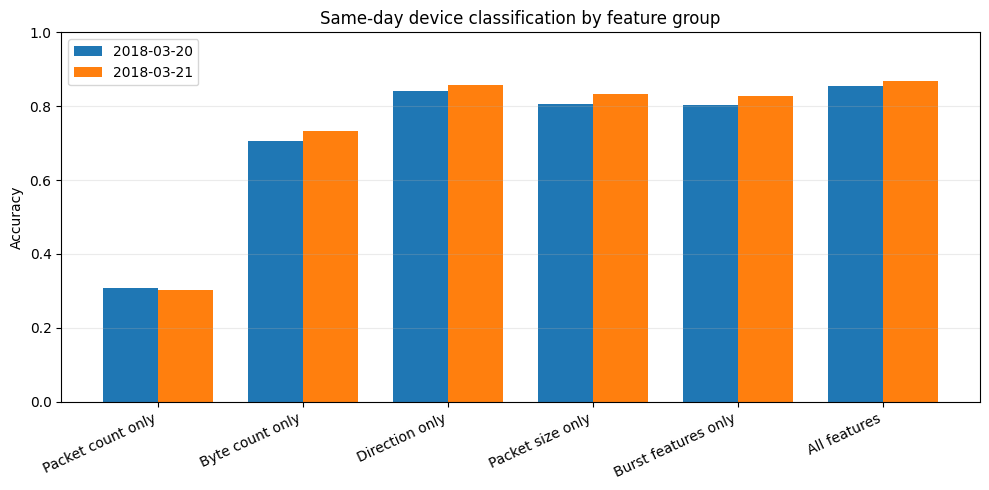

In [9]:
plot_df = results.copy()
plot_df["feature_group"] = pd.Categorical(
    plot_df["feature_group"],
    categories=list(feature_groups),
    ordered=True,
)
plot_df = plot_df.sort_values(["feature_group", "day"])

fig, ax = plt.subplots(figsize=(10, 5))
width = 0.38
x = np.arange(len(feature_groups))

for offset, day in [(-width / 2, "2018-03-20"), (width / 2, "2018-03-21")]:
    values = plot_df[plot_df["day"] == day].set_index("feature_group").loc[list(feature_groups), "accuracy"]
    ax.bar(x + offset, values, width=width, label=day)

ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("Same-day device classification by feature group")
ax.set_xticks(x)
ax.set_xticklabels(list(feature_groups), rotation=25, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

In [10]:
top_importances = (
    importances
    .sort_values(["day", "importance"], ascending=[True, False])
    .groupby("day")
    .head(8)
    .reset_index(drop=True)
)

top_importances

,day,feature,importance
0,2018-03-20,max_pkt_size,0.113845
1,2018-03-20,avg_pkt_size,0.098089
2,2018-03-20,bytes_per_packet,0.094144
3,2018-03-20,pkt_size_range,0.079293
4,2018-03-20,outgoing_bytes,0.076381
5,2018-03-20,byte_burst_score,0.073730
6,2018-03-20,total_bytes,0.072777
7,2018-03-20,min_pkt_size,0.064095
8,2018-03-21,max_pkt_size,0.120683
9,2018-03-21,avg_pkt_size,0.098492


## Cross-Day Feature Ablation

In [11]:
def filter_common_labels(train_df, test_df, min_samples=10):
    train_counts = train_df["label"].value_counts()
    test_counts = test_df["label"].value_counts()
    labels = sorted(
        set(train_counts[train_counts >= min_samples].index)
        & set(test_counts[test_counts >= min_samples].index)
    )
    return (
        train_df[train_df["label"].isin(labels)].copy(),
        test_df[test_df["label"].isin(labels)].copy(),
        labels,
    )


feature_dfs = {
    day: add_basic_features(pd.read_csv(path))
    for day, path in feature_files.items()
}

cross_day_pairs = [
    ("2018-03-20 -> 2018-03-21", "2018-03-20", "2018-03-21"),
    ("2018-03-21 -> 2018-03-20", "2018-03-21", "2018-03-20"),
]

cross_day_pairs

[('2018-03-20 -> 2018-03-21', '2018-03-20', '2018-03-21'),
 ('2018-03-21 -> 2018-03-20', '2018-03-21', '2018-03-20')]

In [12]:
cross_rows = []
cross_importance_rows = []
cross_threshold_rows = []

for experiment, train_day, test_day in cross_day_pairs:
    train_df, test_df, labels = filter_common_labels(feature_dfs[train_day], feature_dfs[test_day])
    train_df, test_df, thresholds = add_burst_features(train_df, test_df)
    cross_threshold_rows.append({
        "experiment": experiment,
        "train_day": train_day,
        "test_day": test_day,
        **thresholds,
    })

    print(f"{experiment}: train={len(train_df):,}, test={len(test_df):,}, common_devices={len(labels)}")
    for group, cols in feature_groups.items():
        clf, result = evaluate_group(train_df, test_df, group, cols)
        result.update({
            "experiment": experiment,
            "train_day": train_day,
            "test_day": test_day,
            "n_devices": len(labels),
        })
        cross_rows.append(result)
        print(f"  {group:22s} accuracy={result['accuracy']:.4f}, macro_f1={result['macro_f1']:.4f}")

        if group == "All features":
            for feature, importance in sorted(
                zip(cols, clf.feature_importances_),
                key=lambda item: item[1],
                reverse=True,
            ):
                cross_importance_rows.append({
                    "experiment": experiment,
                    "feature": feature,
                    "importance": importance,
                })

cross_day_results = pd.DataFrame(cross_rows)
cross_day_importances = pd.DataFrame(cross_importance_rows)
cross_day_thresholds = pd.DataFrame(cross_threshold_rows)

cross_day_results

2018-03-20 -> 2018-03-21: train=257,066, test=290,398, common_devices=44
  Packet count only      accuracy=0.2931, macro_f1=0.1353
  Byte count only        accuracy=0.6532, macro_f1=0.5608
  Direction only         accuracy=0.8147, macro_f1=0.7225
  Packet size only       accuracy=0.8020, macro_f1=0.7002
  Burst features only    accuracy=0.7663, macro_f1=0.6625
  All features           accuracy=0.8517, macro_f1=0.7578
2018-03-21 -> 2018-03-20: train=290,398, test=257,066, common_devices=44
  Packet count only      accuracy=0.2837, macro_f1=0.1272
  Byte count only        accuracy=0.6546, macro_f1=0.5297
  Direction only         accuracy=0.7822, macro_f1=0.6351
  Packet size only       accuracy=0.7618, macro_f1=0.6237
  Burst features only    accuracy=0.7524, macro_f1=0.6105
  All features           accuracy=0.8002, macro_f1=0.6593


,feature_group,accuracy,macro_precision,macro_recall,macro_f1,n_train,n_test,n_devices,features,experiment,train_day,test_day
0,Packet count only,0.293056,0.143538,0.203953,0.135271,257066,290398,44,pkt_count,2018-03-20 -> 2018-03-21,2018-03-20,2018-03-21
1,Byte count only,0.653179,0.569325,0.623724,0.560752,257066,290398,44,total_bytes,2018-03-20 -> 2018-03-21,2018-03-20,2018-03-21
2,Direction only,0.814682,0.748666,0.750192,0.722456,257066,290398,44,"outgoing_pkts, incoming_pkts, outgoing_bytes, ...",2018-03-20 -> 2018-03-21,2018-03-20,2018-03-21
3,Packet size only,0.802017,0.752253,0.728052,0.700162,257066,290398,44,"avg_pkt_size, max_pkt_size, min_pkt_size, pkt_...",2018-03-20 -> 2018-03-21,2018-03-20,2018-03-21
4,Burst features only,0.766321,0.687899,0.703247,0.662540,257066,290398,44,"pkt_burst, byte_burst, both_burst, pkt_burst_s...",2018-03-20 -> 2018-03-21,2018-03-20,2018-03-21
5,All features,0.851697,0.782198,0.782563,0.757834,257066,290398,44,"pkt_count, total_bytes, outgoing_pkts, incomin...",2018-03-20 -> 2018-03-21,2018-03-20,2018-03-21
6,Packet count only,0.283670,0.137226,0.207549,0.127213,290398,257066,44,pkt_count,2018-03-21 -> 2018-03-20,2018-03-21,2018-03-20
7,Byte count only,0.654567,0.538958,0.586961,0.529676,290398,257066,44,total_bytes,2018-03-21 -> 2018-03-20,2018-03-21,2018-03-20
8,Direction only,0.782208,0.670059,0.700935,0.635139,290398,257066,44,"outgoing_pkts, incoming_pkts, outgoing_bytes, ...",2018-03-21 -> 2018-03-20,2018-03-21,2018-03-20
9,Packet size only,0.761820,0.666246,0.671076,0.623662,290398,257066,44,"avg_pkt_size, max_pkt_size, min_pkt_size, pkt_...",2018-03-21 -> 2018-03-20,2018-03-21,2018-03-20


In [13]:
cross_day_importances

,experiment,feature,importance
0,2018-03-20 -> 2018-03-21,max_pkt_size,0.111695
1,2018-03-20 -> 2018-03-21,avg_pkt_size,0.094762
2,2018-03-20 -> 2018-03-21,bytes_per_packet,0.093855
3,2018-03-20 -> 2018-03-21,pkt_size_range,0.079843
4,2018-03-20 -> 2018-03-21,outgoing_bytes,0.077489
5,2018-03-20 -> 2018-03-21,byte_burst_score,0.076963
6,2018-03-20 -> 2018-03-21,total_bytes,0.074705
7,2018-03-20 -> 2018-03-21,min_pkt_size,0.064645
8,2018-03-20 -> 2018-03-21,outgoing_byte_share,0.049521
9,2018-03-20 -> 2018-03-21,incoming_bytes,0.049494


In [14]:
cross_day_thresholds

,experiment,train_day,test_day,pkt_count_q90,total_bytes_q90
0,2018-03-20 -> 2018-03-21,2018-03-20,2018-03-21,123.0,21842.0
1,2018-03-21 -> 2018-03-20,2018-03-21,2018-03-20,218.0,117294.0


In [15]:
cross_accuracy_table = (
    cross_day_results
    .pivot(index="feature_group", columns="experiment", values="accuracy")
    .loc[list(feature_groups)]
)
cross_macro_f1_table = (
    cross_day_results
    .pivot(index="feature_group", columns="experiment", values="macro_f1")
    .loc[list(feature_groups)]
)

cross_accuracy_table

experiment,2018-03-20 -> 2018-03-21,2018-03-21 -> 2018-03-20
feature_group,,
Packet count only,0.293056,0.283670
Byte count only,0.653179,0.654567
Direction only,0.814682,0.782208
Packet size only,0.802017,0.761820
Burst features only,0.766321,0.752402
All features,0.851697,0.800226


In [16]:
cross_macro_f1_table

experiment,2018-03-20 -> 2018-03-21,2018-03-21 -> 2018-03-20
feature_group,,
Packet count only,0.135271,0.127213
Byte count only,0.560752,0.529676
Direction only,0.722456,0.635139
Packet size only,0.700162,0.623662
Burst features only,0.662540,0.610519
All features,0.757834,0.659304


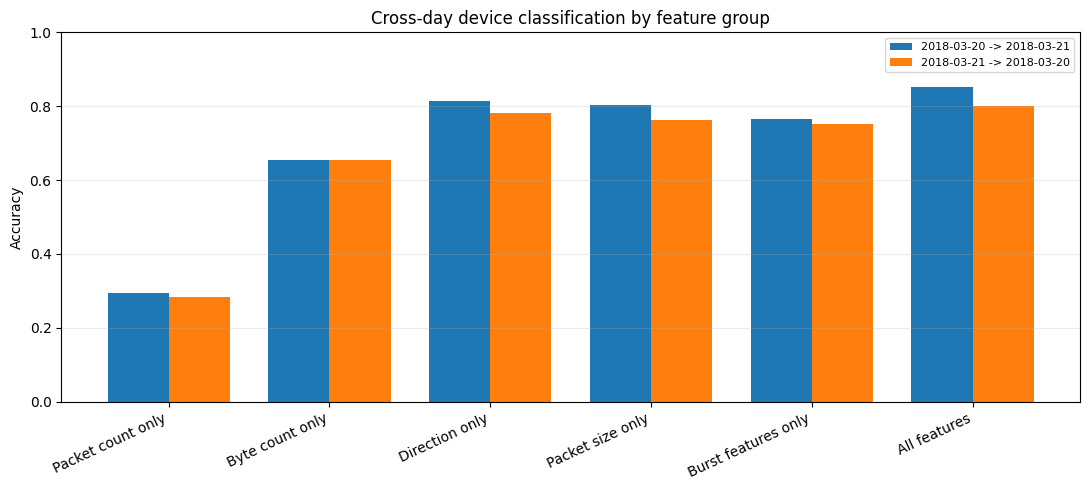

In [17]:
plot_df = cross_day_results.copy()
plot_df["feature_group"] = pd.Categorical(
    plot_df["feature_group"],
    categories=list(feature_groups),
    ordered=True,
)
plot_df = plot_df.sort_values(["feature_group", "experiment"])

fig, ax = plt.subplots(figsize=(11, 5))
width = 0.38
x = np.arange(len(feature_groups))

for offset, experiment in [(-width / 2, cross_day_pairs[0][0]), (width / 2, cross_day_pairs[1][0])]:
    values = plot_df[plot_df["experiment"] == experiment].set_index("feature_group").loc[list(feature_groups), "accuracy"]
    ax.bar(x + offset, values, width=width, label=experiment)

ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("Cross-day device classification by feature group")
ax.set_xticks(x)
ax.set_xticklabels(list(feature_groups), rotation=25, ha="right")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

In [12]:
cross_top_importances = (
    cross_day_importances
    .sort_values(["experiment", "importance"], ascending=[True, False])
    .groupby("experiment")
    .head(8)
    .reset_index(drop=True)
)

display(cross_top_importances.style.format({"importance": "{:.4f}"}))

,experiment,feature,importance
0,Train 2018-03-20 -> Test 2018-03-21,max_pkt_size,0.1117
1,Train 2018-03-20 -> Test 2018-03-21,avg_pkt_size,0.0948
2,Train 2018-03-20 -> Test 2018-03-21,bytes_per_packet,0.0939
3,Train 2018-03-20 -> Test 2018-03-21,pkt_size_range,0.0798
4,Train 2018-03-20 -> Test 2018-03-21,outgoing_bytes,0.0775
5,Train 2018-03-20 -> Test 2018-03-21,byte_burst_score,0.0770
6,Train 2018-03-20 -> Test 2018-03-21,total_bytes,0.0747
7,Train 2018-03-20 -> Test 2018-03-21,min_pkt_size,0.0646
8,Train 2018-03-21 -> Test 2018-03-20,max_pkt_size,0.1170
9,Train 2018-03-21 -> Test 2018-03-20,bytes_per_packet,0.0995
